In [7]:
import cv2
import numpy as np
import random
import math
from matplotlib import pyplot as plt
from collections import deque
import heapq

from image_processing import (
    load_and_process_image,
    split_into_cells,
    detect_maze_walls,
    synchronise_walls,
    display_occupancy_map
)

from graph import (
    create_grid_graph,
    add_valid_edges,
    print_maze,
    print_maze_with_path
)

from path_finder import (
    command_optimal_path,
    path_to_commands,
    command_optimal_path_to_obstacles
)
random.seed(13)

# Note: general Claude usage for debugging purposes, checking python syntax and for some code generation 

# SYSTEM PARAMETERS

You are free to change the value of these variables for testing, but do not add extra variables here. This entire block will be replaced when marking.

In [8]:
# DO NOT ADD OTHER VARIABLES HERE

# General settings
seed = 13
image_file = "./maze_images/map1obstacles.jpg"

# Task 1 - Occupancy map
unsafe_kernel_size = 7
unsafe_iterations = 3

top_left_obstacle_box_cell = 27
obstacle_box_width = 5

bfs_n = 9
bfs_start_node = 31
bfs_end_node = 65

# Task 5 - RRT
rrt_max_nodes_count = 680
rrt_step_size = 50
rrt_max_connection_length = 70
rrt_start_location = (50,50)
rrt_goal_location = (150,350)

# DO NOT ADD OTHER VARIABLES HERE

# Task 1 - OCCUPANCY MAP (4 marks total)

In [9]:
# Task 1.1 (1 mark): Display the occupancy map
binary = load_and_process_image(image_file)
cells, cell_width, cell_height = split_into_cells(binary, bfs_n)
print("Image size:", binary.shape[1], "x", binary.shape[0])
print("Cell size:", cell_width, "x", cell_height)
display_occupancy_map(binary, cell_width, cell_height, bfs_n)

FileNotFoundError: Could not load image: ./maze_images/map1obstacles.jpg

In [ ]:
# ---------------------------------------------------------

# 2. Detect maze walls

# ---------------------------------------------------------

maze = detect_maze_walls(cells, bfs_n)

# ---------------------------------------------------------

# 3. Create graph representation

# ---------------------------------------------------------

graph = create_grid_graph(bfs_n)
synchronise_walls(graph, maze, bfs_n)
add_valid_edges(graph, bfs_n)

# print("\nDetected maze:")
# print_maze(graph, bfs_n, bfs_n)

# ---------------------------------------------------------

# 4. Find path using BFS

# ---------------------------------------------------------
# path, commands = command_optimal_path(graph, bfs_start_node, bfs_end_node, start_direction="N")
path_to_start_obst, commands_start = command_optimal_path_to_obstacles(graph, bfs_start_node, top_left_obstacle_box_cell, course_width = 4, start_direction="N", cols=9)
path_to_end_obst, commands_end = command_optimal_path_to_obstacles(graph, bfs_end_node, top_left_obstacle_box_cell, course_width = 4, start_direction="N", cols=9)


if path_to_start_obst is None:
    print("\nNo path found.")
else:
    # Display the digital maze with the BFS path traced.
    print("\nDigital maze with path:")
    print_maze_with_path(graph, path_to_start_obst, bfs_n, bfs_n)
    print("\nPath:", path_to_start_obst)
    print("Number of moves:", len(path_to_start_obst) - 1)

if path_to_end_obst is None:
    print("\nNo path found.")
else:
    # Display the digital maze with the BFS path traced.
    print("\nDigital maze with path:")
    print_maze_with_path(graph, path_to_end_obst, bfs_n, bfs_n)
    print("\nPath:", path_to_end_obst)
    print("Number of moves:", len(path_to_end_obst) - 1)



Digital maze with path:
+---+---+---+---+---+---+---+---+---+
|       | •   •   •   •   • |        
+   +---+   +   +---+---+   +---+   +
    |   | • |   |     •   •     |    
+---+   +   +---+   +   +---+---+---+
| •   •   • |       | •         |   |
+   +---+---+---+---+   +---+---+   +
| G             | S   •         |   |
+---+   +   +   +---+---+---+---+   +
|   |           |   |   |   |       |
+   +   +   +   +   +   +   +   +   +
|   |       |                   |   |
+   +---+   +   +---+---+---+   +   +
|               |   |       |   |   |
+---+---+---+---+   +---+   +   +---+
        |   |                   |    
+   +---+   +---+   +---+---+---+   +
        |                   |       |
+   +   +---+---+---+---+---+   +---+

Path: [31, 32, 23, 14, 15, 6, 5, 4, 3, 2, 11, 20, 19, 18, 27]
Number of moves: 14

Digital maze with path:
+---+---+---+---+---+---+---+---+---+
|       |                   |        
+   +---+   +   +---+---+   +---+   +
    |   |   |   |              

# Task 2 - Graph Class (0 marks total)

NOTE: This is slightly different to the graph in lab 07. x,y variables have been added to the node object.

In [ ]:
# This is a useful function that you may choose to implement and use 
# It looks through the image to see if the path is clear between one coordinate to the next
# Returns True or False 
def path_clear(image_to_analyse, x1, y1, x2, y2):
    n = int(np.ceil(np.sqrt((x2 - x1)**2 + (y2 - y1)**2)) + 1)
    x_coords = np.linspace(x1, x2, n).astype(int)
    y_coords = np.linspace(y1, y2, n).astype(int)
    colour_vals_actual = image_to_analyse[y_coords, x_coords]

    x_coords = np.linspace(x1 + 1, x2 + 1, n).astype(int)
    y_coords = np.linspace(y1, y2, n).astype(int)
    colour_vals_right = image_to_analyse[y_coords, x_coords]

    x_coords = np.linspace(x1, x2, n).astype(int)
    y_coords = np.linspace(y1 + 1, y2 + 1, n).astype(int)
    colour_vals_down = image_to_analyse[y_coords, x_coords]

    x_coords = np.linspace(x1 - 1, x2 - 1, n).astype(int)
    y_coords = np.linspace(y1, y2, n).astype(int)
    colour_vals_left = image_to_analyse[y_coords, x_coords]

    x_coords = np.linspace(x1, x2, n).astype(int)
    y_coords = np.linspace(y1 - 1, y2 - 1, n).astype(int)
    colour_vals_up = image_to_analyse[y_coords, x_coords]

    # Because both of the valid areas have no green values
    if np.any(colour_vals_actual[:, 1] == 0) or np.any(colour_vals_left[:, 1] == 0) or np.any(colour_vals_right[:, 1] == 0)\
        or np.any(colour_vals_up[:, 1] == 0) or np.any(colour_vals_down[:, 1] == 0):
        return False
    return True 

# Task 5 - Rapidly-exploring random trees (RRT) (7 marks total)

In [ ]:
def cartesian_distance(x1, y1, x2, y2):
    return math.sqrt((x2-x1)**2 + (y2-y1)**2)

class RRT_Node:
    def __init__(self, node_id, x, y, parent = None, cost = 0.0):
        self.id = node_id
        self.x = x
        self.y = y
        self.children = []
        self.parent = parent
        self.cost = cost
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id 

    def add_child(self, child_node):
        self.children.append(child_node)

def nearest_node(tree, sample_x, sample_y):
    sample = RRT_Node(-1, sample_x, sample_y)  # temp node just to reuse distance()
    return min(tree, key=lambda n: cartesian_distance(n.x, n.y, sample.x, sample.y))

def steer(from_node, to_x, to_y):
    dist = cartesian_distance(to_x, to_y, from_node.x, from_node.y)
    if dist <= rrt_step_size:
        return to_x, to_y
    theta = math.atan2(to_y - from_node.y, to_x - from_node.x)
    new_x = from_node.x + rrt_step_size * math.cos(theta)
    new_y = from_node.y + rrt_step_size * math.sin(theta)
    return new_x, new_y

def near_nodes(tree, new_node):
    return [n for n in tree if cartesian_distance(n.x, n.y, new_node.x, new_node.y) <= rrt_max_connection_length]

def extend(tree, new_node, image):
    # 1. Pick the best parent among nearby nodes (not just the literal nearest)
    candidates = near_nodes(tree, new_node)
    if not candidates:
        return None  # no valid parent nearby

    best_parent = None
    best_cost = float('inf')
    for candidate in candidates:
        if path_clear(image, candidate.x, candidate.y, new_node.x, new_node.y):
            cost = candidate.cost + cartesian_distance(candidate.x, candidate.y, new_node.x, new_node.y)
            if cost < best_cost:
                best_cost = cost
                best_parent = candidate

    if best_parent is None:
        return None  # every candidate was blocked

    new_node.parent = best_parent
    new_node.cost = best_cost
    best_parent.children.append(new_node)
    tree.append(new_node)

    # 2. Rewire: check if new_node offers a cheaper path to its neighbors
    for candidate in candidates:
        if candidate is best_parent:
            continue
        potential_cost = new_node.cost + cartesian_distance(new_node.x, new_node.y, candidate.x, candidate.y)
        if potential_cost < candidate.cost and path_clear(image, new_node.x, new_node.y, candidate.x, candidate.y):
            # detach from old parent
            if candidate.parent is not None:
                candidate.parent.children.remove(candidate)
            candidate.parent = new_node
            propagate_cost(candidate, potential_cost - candidate.cost)
            new_node.children.append(candidate)

    return new_node

def propagate_cost(node, delta):
    # After a rewire, push the cost change down to all descendants
    node.cost += delta
    for child in node.children:
        propagate_cost(child, delta)

def get_path(goal_node):
    path = []
    current = goal_node
    while current is not None:
        path.append(current.get_point())
        current = current.parent
    path.reverse()
    return path

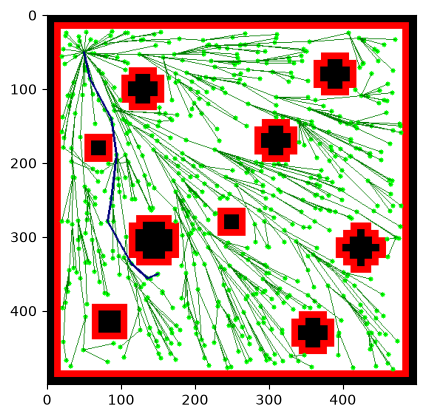

In [ ]:
# Task 5.1 (4 marks): RRT/RRT*
# NOTE: The iteration only increases when a valid node is placed on the map. If the node is invalid, the program should continue without incrementing the node count. 
rrt_image = cv2.imread(image_file)
rrt_image = make_occupancy_map(rrt_image)
goal_bias = 0.05
random.seed(seed)

# Generate the start node with a node ID of -1
root = RRT_Node(-1, rrt_start_location[0], rrt_start_location[1], None, 0.0)
rrt_tree = [root]
goal_node = None

i = 0
while i < rrt_max_nodes_count:
    if random.random() < goal_bias:
        sample_x, sample_y = rrt_goal_location[0], rrt_goal_location[1]
    else:
        sample_x = random.randint(0, rrt_image.shape[1]-1)
        sample_y = random.randint(0, rrt_image.shape[0]-1)

    nearest = nearest_node(rrt_tree, sample_x, sample_y)
    new_x, new_y = steer(nearest, sample_x, sample_y)
    new_x, new_y = int(round(new_x)), int(round(new_y))

    # snap on if goal isnt created yet and within distance
    dist_to_goal = cartesian_distance(new_x, new_y, rrt_goal_location[0], rrt_goal_location[1])
    if goal_node is None and dist_to_goal <= rrt_step_size:
        new_x, new_y = rrt_goal_location

    # Potential node collision checks
    if rrt_image[new_y, new_x, 1] != 255 or not path_clear(rrt_image, nearest.x, nearest.y, new_x, new_y):
        continue

    new_node = RRT_Node(i, new_x, new_y)
    new_node = extend(rrt_tree, new_node, rrt_image)
    if new_node is None:
        continue

    if goal_node is None and new_node.x == rrt_goal_location[0] and new_node.y == rrt_goal_location[1]:
        goal_node = new_node

    cv2.circle(rrt_image, new_node.get_point(), 3, (0, 255, 0), -1)
    
    i += 1


cv2.circle(rrt_image, root.get_point(), 3, (0, 255, 0), -1)

for node in rrt_tree:
    for child in node.children:
        cv2.line(rrt_image, node.get_point(), child.get_point(), (0, 125, 0), 1)

path = get_path(goal_node)

prev_i, prev_j = root.get_point()

for i in range(1, len(path)):
    cur_i, cur_j = path[i]
    cv2.line(rrt_image, (prev_i, prev_j), (cur_i, cur_j), (0, 0, 125), 2)

    prev_i = cur_i
    prev_j = cur_j

# Display the resulting image
plt.imshow(rrt_image)
plt.show()
